In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
base_model_predictions = pd.read_csv('trained_models/2025-06-05-10/fold_1_EPInformer-PE-Activity-HiC.preTrainedConv.4base.64dim.3Trans.4head.TrueBN.TrueLN.TrueFeat.3extraFeat.60enh.Trueexon.K562.multi_predictions.csv')

comparison_model_predictions = pd.read_csv('trained_models/2025-06-06-16/fold_1_EPInformer-PE-Activity-HiC.preTrainedConv.4base.64dim.5Trans.8head.TrueBN.TrueLN.TrueFeat.3extraFeat.60enh.Trueexon.K562.multi_predictions.csv')
comparison_model_predictions

,Unnamed: 0,PredExpr,ActualExpr,PredPsi,ActualPsi,fold_idx
0,ENSG00000196388,1.467489,-0.823909,-0.210451,1.0,1
1,ENSG00000164051,1.422609,1.109916,-0.206500,1.0,1
2,ENSG00000064102,1.486485,1.707059,-0.299450,1.0,1
3,ENSG00000064102,1.487744,1.707059,-0.291516,1.0,1
4,ENSG00000064102,1.485087,1.707059,-0.293354,1.0,1
...,...,...,...,...,...,...
2480,ENSG00000106397,1.521885,1.317646,-0.371667,1.0,1
2481,ENSG00000106397,1.521902,1.317646,-0.371921,1.0,1
2482,ENSG00000106397,1.521998,1.317646,-0.372507,1.0,1
2483,ENSG00000134769,1.357967,0.045323,-0.144359,1.0,1


In [3]:
def plot_predictions(predictions_base, predictions_comparison, cell_line, pred_col, actual_col):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Base Model
    pearsonR, _ = stats.pearsonr(predictions_base[pred_col], predictions_base[actual_col])
    sns.scatterplot(
        data=predictions_base,
        x=pred_col,
        y=actual_col,
        ax=axes[0],
        s=10, alpha=0.5, linewidth=0
    )
    sns.regplot(
        data=predictions_base,
        x=pred_col,
        y=actual_col,
        ax=axes[0],
        scatter=False,
        color="orange",
        line_kws={"linestyle": "dashed"}
    )
    axes[0].set_title(f"{cell_line} Base Model\nPearson R: {pearsonR:.2f}")

    # Comparison Model
    pearsonR, _ = stats.pearsonr(predictions_comparison[pred_col], predictions_comparison[actual_col])
    sns.scatterplot(
        data=predictions_comparison,
        x=pred_col,
        y=actual_col,
        ax=axes[1],
        s=10, alpha=0.5, linewidth=0
    )
    sns.regplot(
        data=predictions_comparison,
        x=pred_col,
        y=actual_col,
        ax=axes[1],
        scatter=False,
        color="orange",
        line_kws={"linestyle": "dashed"}
    )
    axes[1].set_title(f"{cell_line} Comparison Model\nPearson R: {pearsonR:.2f}")

    plt.tight_layout()
    plt.show()


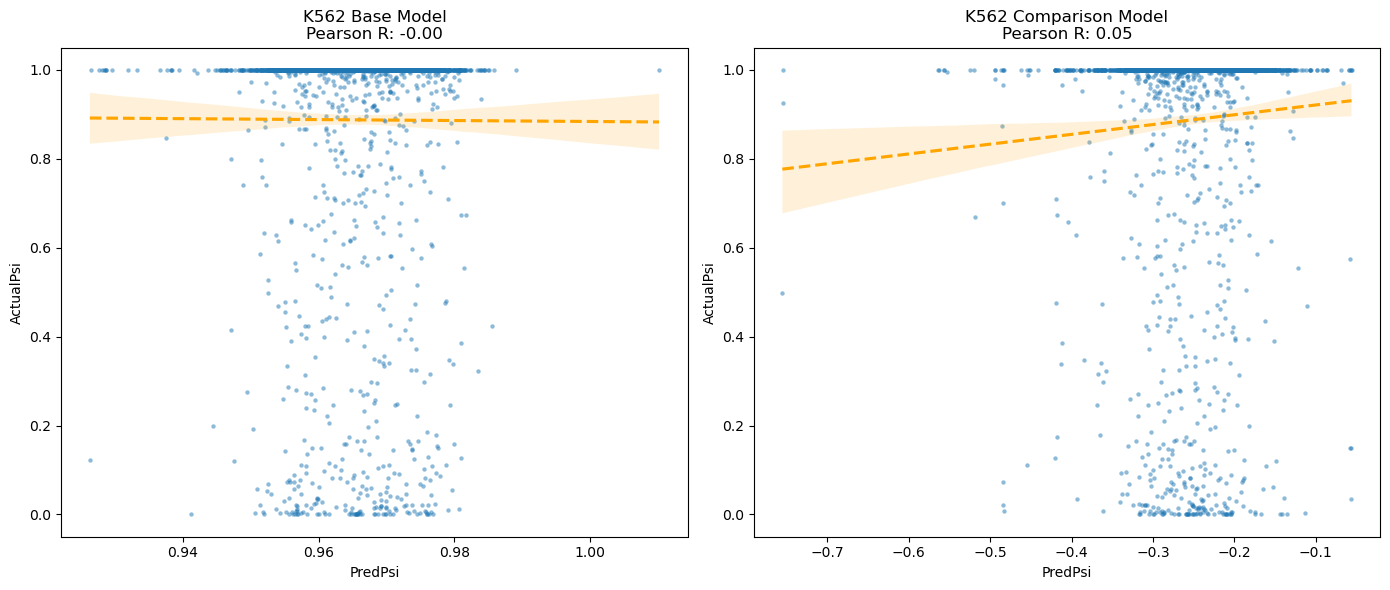

In [4]:
plot_predictions(
    base_model_predictions,
    comparison_model_predictions,
    cell_line='K562', 
    pred_col='PredPsi', 
    actual_col='ActualPsi'
)

In [5]:
def plot_predictions(predictions, cell_line, pred_col, actual_col):
    pearsonR, _ = stats.pearsonr(predictions[pred_col], predictions[actual_col])
    plt.figure(figsize=(6,6))
    ax = sns.jointplot(
        data=predictions,
        x=pred_col,
        y=actual_col,
        kind = 'scatter',
        joint_kws={'marker':'o', 's':10, 'alpha':0.5, 'linewidth':0},
        marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
    )
    prediction_task = 'PSI' if 'Psi' in pred_col else 'Expression'
    ax.plot_joint(sns.regplot, color="r", scatter=False, line_kws={"color": "orange", 'linestyle':'dashed'})
    plt.title(f"{cell_line} {prediction_task} Prediction (Pearson R: {pearsonR:.2f})")
    plt.ylabel(f'{cell_line} {prediction_task} (actual)')
    plt.xlabel(f'{cell_line} {prediction_task} (predicted)')
    if prediction_task == 'PSI':
        plt.xlim(-0.1, 1.1)
        plt.ylim(-0.1, 1.1)
    plt.tight_layout()

<Figure size 600x600 with 0 Axes>

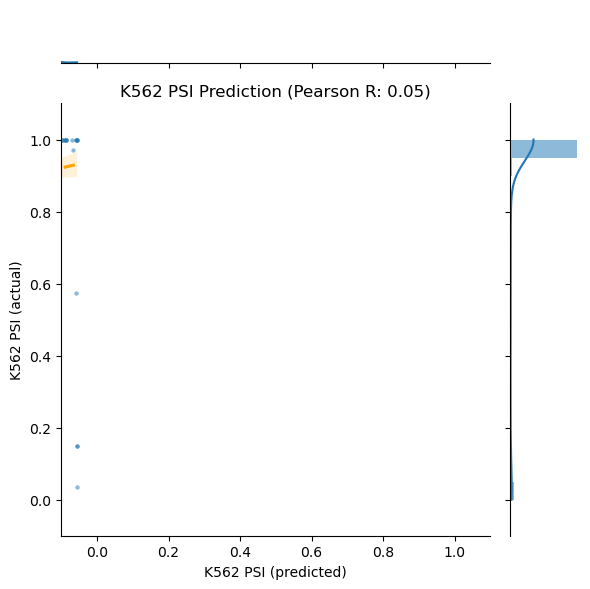

In [6]:
plot_predictions(comparison_model_predictions, cell_line='K562', pred_col='PredPsi', actual_col='ActualPsi')